# Exploratory Data Analysis

This notebook explores the RAVDESS speech emotion dataset used to train the emotion recognition model.

## Imports

In [4]:
from pathlib import Path
from collections import Counter
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Emotion Distribution

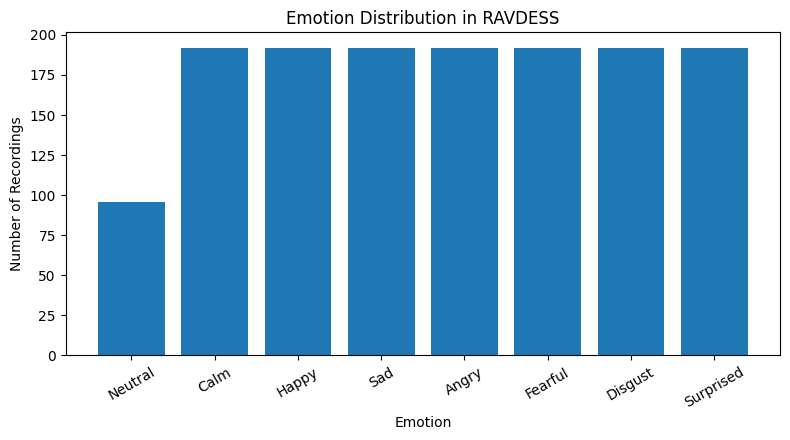

In [5]:
data_dir = Path("data/audio_speech_actors_01-24")

emotion_map = {
    1: "Neutral",
    2: "Calm",
    3: "Happy",
    4: "Sad",
    5: "Angry",
    6: "Fearful",
    7: "Disgust",
    8: "Surprised",
}

emotion_ids = []

for wav in data_dir.rglob("*.wav"):
    emotion = int(wav.stem.split("-")[2])
    emotion_ids.append(emotion)

counts = Counter(emotion_ids)

labels = [emotion_map[i] for i in range(1, 9)]
values = [counts[i] for i in range(1, 9)]

plt.figure(figsize=(8, 4.5))
plt.bar(labels, values)

plt.title("Emotion Distribution in RAVDESS")
plt.xlabel("Emotion")
plt.ylabel("Number of Recordings")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

The RAVDESS dataset is balanced across emotion classes, with the exception of *Neutral*, which contains half as many recordings as the remaining emotions.

## Clip Durations

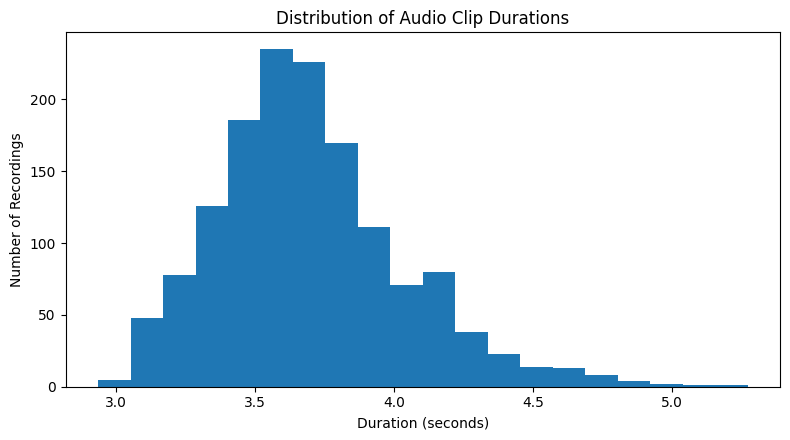

Min:  2.94 s
Mean: 3.70 s
Max:  5.27 s


In [6]:
durations = []

data_dir = Path("data/audio_speech_actors_01-24")

for wav in data_dir.rglob("*.wav"):
    duration = librosa.get_duration(path=wav)
    durations.append(duration)

plt.figure(figsize=(8, 4.5))

plt.hist(durations, bins=20)

plt.title("Distribution of Audio Clip Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Recordings")

plt.tight_layout()

plt.show()

print(f"Min:  {np.min(durations):.2f} s")
print(f"Mean: {np.mean(durations):.2f} s")
print(f"Max:  {np.max(durations):.2f} s")

In [7]:
durations = np.array(durations)

longer = np.sum(durations > 4.0)
equal_or_shorter = np.sum(durations <= 4.0)

print(f"Total clips: {len(durations)}")
print(f"Longer than 4 s: {longer} ({100*longer/len(durations):.1f}%)")
print(f"4 s or shorter: {equal_or_shorter} ({100*equal_or_shorter/len(durations):.1f}%)")

Total clips: 1440
Longer than 4 s: 255 (17.7%)
4 s or shorter: 1185 (82.3%)


A duration of 4 seconds was selected for preprocessing, as 82.3% of recordings are already 4 seconds or shorter. Only 17.7% of recordings require truncation, while shorter recordings are zero-padded to produce fixed-length inputs.

## Speaker-Independent Split

In [ ]:
from src.split import get_ravdess_split

train_files, test_files = get_ravdess_split()

pd.DataFrame({
    "Split": ["Training", "Testing"],
    "Actors": ["1–20", "21–24"],
    "Recordings": [len(train_files), len(test_files)]
})

ModuleNotFoundError: No module named 'split'